In [2]:
# ===================================================================
# CELL 1: SETUP AND INITIAL DATA LOADING
# ===================================================================
import pandas as pd
import re
import spacy
import emoji
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os

# --- Define file paths ---
# This assumes your notebook is in the 'notebook' folder, so we go up one level
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR = os.path.join(project_root, "data")
RAW_DATA_PATH = os.path.join(DATA_DIR, "word_sentiment_lexicon.csv")
PROCESSED_OUTPUT_PATH = os.path.join(DATA_DIR, "preprocessed_for_graph.csv")

# --- Load the raw dataset ---
print("Loading raw dataset...")
df_raw = pd.read_csv(RAW_DATA_PATH)

# --- Load spaCy model ---
print("Loading spaCy NLP model for tokenization...")
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

print("\n--- Initial Raw Data ---")
print(f"Shape of the dataset: {df_raw.shape}")
print("A look at the first 5 rows:")
# Use display() for better formatting in Jupyter
display(df_raw.head())

Loading raw dataset...
Loading spaCy NLP model for tokenization...

--- Initial Raw Data ---
Shape of the dataset: (2045, 10)
A look at the first 5 rows:


,word,rootWord,sentimentTag,sentimentStrength,partOfSpeech,definition,exampleSentence,domain,relatedWords,isNegatable
0,kastam,kastam,neutral,0.0,noun,Jabatan kerajaan yang bertanggungjawab menguti...,Barang yang diimport itu akan melalui pemeriks...,"government, trade","['duti', 'cukai', 'sempadan', 'imigresen']",False
1,phone,telefon,neutral,0.0,noun,Alat telekomunikasi untuk bercakap dengan oran...,Saya perlu membeli phone baru.,technology,"['telefon bimbit', 'gajet', 'komunikasi']",False
2,Inilah,ini,neutral,0.0,demonstrative pronoun,"Bentuk penekanan bagi 'ini', merujuk kepada se...",Inilah yang saya cari selama ini.,general,"['itulah', 'ini', 'begitulah']",True
3,this,ini,neutral,0.0,demonstrative pronoun,Ini (kata ganti tunjuk bahasa Inggeris).,This is my book.,general,"['itu', 'ini']",True
4,.orang,orang,neutral,0.0,noun,Manusia; individu.,Ramai .orang hadir ke majlis itu.,general,"['individu', 'manusia', 'masyarakat']",True


In [3]:
# ===================================================================
# CELL 2: STEP 1 - COLUMN FILTERING & CLEANING
# ===================================================================
print("--- Applying Step 1: Column Filtering & Row Cleaning ---")
print(f"Original number of rows: {len(df_raw)}")

# 1a. Keep only the required columns
df_step1 = df_raw[["exampleSentence", "partOfSpeech", "sentimentTag", "sentimentStrength"]].copy()

# 1b. Drop rows where the sentence is empty/invalid
df_step1.dropna(subset=['exampleSentence'], inplace=True)
df_step1 = df_step1[df_step1["exampleSentence"].str.strip() != ""]

print(f"Number of rows after cleaning: {len(df_step1)}")
print("\n--- Data after Step 1 ---")
display(df_step1.head())

--- Applying Step 1: Column Filtering & Row Cleaning ---
Original number of rows: 2045
Number of rows after cleaning: 2044

--- Data after Step 1 ---


,exampleSentence,partOfSpeech,sentimentTag,sentimentStrength
0,Barang yang diimport itu akan melalui pemeriks...,noun,neutral,0.0
1,Saya perlu membeli phone baru.,noun,neutral,0.0
2,Inilah yang saya cari selama ini.,demonstrative pronoun,neutral,0.0
3,This is my book.,demonstrative pronoun,neutral,0.0
4,Ramai .orang hadir ke majlis itu.,noun,neutral,0.0


In [3]:
# ===================================================================
# CELL 3: STEP 2 - TRANSLATING EMOJIS
# ===================================================================
def demojize_and_clean(text: str) -> str:
    s = emoji.demojize(text, language='en')
    return re.sub(r":(.*?):", lambda m: m.group(1).replace("_", " "), s)

# Create a new column for our progressive cleaning
df_step2 = df_step1.copy()
df_step2["cleanSentence"] = df_step2["exampleSentence"].astype(str).apply(demojize_and_clean)

print("--- Visualization for Step 2: Emoji Translation ---")
# Filter to show only rows that actually had an emoji to demonstrate the change
emoji_examples = df_step2[df_step2['exampleSentence'] != df_step2['cleanSentence']]
display(emoji_examples[['exampleSentence', 'cleanSentence']].head())

--- Visualization for Step 2: Emoji Translation ---


,exampleSentence,cleanSentence
14,Kerja awak memang ✌️👌👍!,Kerja awak memang victory handOK handthumbs up!
177,Kami telah berjaya menamatkan projek ini 🏁🏁🏁.,Kami telah berjaya menamatkan projek ini chequ...
178,Makan sambil berdiri itu haram😁 katanya.,Makan sambil berdiri itu harambeaming face wit...
410,Dia berasa 😔 setelah mendengar berita itu.,Dia berasa pensive face setelah mendengar beri...
437,Apa khabar kamu..😂,Apa khabar kamu..face with tears of joy


In [4]:
# ===================================================================
# CELL 4: STEP 3 - LOWER CASING
# ===================================================================
df_step3 = df_step2.copy()
df_step3["cleanSentence"] = df_step3["cleanSentence"].str.lower()

print("--- Visualization for Step 3: Lowercasing ---")
# Display a sample to show the change
display(df_step3[['exampleSentence', 'cleanSentence']].head())

--- Visualization for Step 3: Lowercasing ---


,exampleSentence,cleanSentence
0,Barang yang diimport itu akan melalui pemeriks...,barang yang diimport itu akan melalui pemeriks...
1,Saya perlu membeli phone baru.,saya perlu membeli phone baru.
2,Inilah yang saya cari selama ini.,inilah yang saya cari selama ini.
3,This is my book.,this is my book.
4,Ramai .orang hadir ke majlis itu.,ramai .orang hadir ke majlis itu.


In [5]:
# ===================================================================
# CELL 5: STEP 4 - PUNCTUATION NORMALIZATION
# ===================================================================
def clean_and_normalize_punctuation(text: str) -> str:
    text = re.sub(r'([!?.,])\1+', r'\1', text)  # Collapse repeated punctuation
    text = re.sub(r'([!?.,])', r' \1 ', text)   # Add space around punctuation
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    return text

df_step4 = df_step3.copy()
df_step4["cleanSentence"] = df_step4["cleanSentence"].apply(clean_and_normalize_punctuation)

print("--- Visualization for Step 4: Punctuation Normalization ---")
# Find examples with messy punctuation to demonstrate the change
messy_punc_examples = df_step4[df_step4['exampleSentence'].str.contains(r'\.\.|,,|^\s+|\s+$', na=False, regex=True)]
display(messy_punc_examples[['exampleSentence', 'cleanSentence']].head())

--- Visualization for Step 4: Punctuation Normalization ---


,exampleSentence,cleanSentence
7,"Dia membeli epal,, oren dan pisang.","dia membeli epal , oren dan pisang ."
16,Mari kita.. pergi bersama.,mari kita . pergi bersama .
17,"Dia makan nasi, ..pastu minum air.","dia makan nasi , . pastu minum air ."
20,"Berita tentang perampok,,takut itu tersebar luas.","berita tentang perampok , takut itu tersebar l..."
23,Dia datang jugak.. walaupun lambat.,dia datang jugak . walaupun lambat .


In [6]:
# ===================================================================
# CELL 6: STEP 5 - TOKENIZATION
# ===================================================================
df_step5 = df_step4.copy()
tokens_list = []
for doc in nlp.pipe(df_step5["cleanSentence"].astype(str), batch_size=50):
    tokens_list.append([token.text for token in doc if not token.is_space])

df_step5["tokens"] = tokens_list

# Create the final processed DataFrame to match the script's output
processed_df = df_step5[["exampleSentence", "partOfSpeech", "sentimentTag", "sentimentStrength", "tokens"]]

print("--- Data after Step 5 (Tokenization) ---")
print("The 'cleanSentence' has been converted into a list of 'tokens'.")
display(processed_df[['exampleSentence', 'tokens']].head())

# Save the final result to be used by other scripts
print(f"\nSaving final processed data to {PROCESSED_OUTPUT_PATH}...")
processed_df.to_csv(PROCESSED_OUTPUT_PATH, index=False)
print("File saved successfully.")

--- Data after Step 5 (Tokenization) ---
The 'cleanSentence' has been converted into a list of 'tokens'.


,exampleSentence,tokens
0,Barang yang diimport itu akan melalui pemeriks...,"[barang, yang, diimport, itu, akan, melalui, p..."
1,Saya perlu membeli phone baru.,"[saya, perlu, membeli, phone, baru, .]"
2,Inilah yang saya cari selama ini.,"[inilah, yang, saya, cari, selama, ini, .]"
3,This is my book.,"[this, is, my, book, .]"
4,Ramai .orang hadir ke majlis itu.,"[ramai, ., orang, hadir, ke, majlis, itu, .]"



Saving final processed data to C:\Users\soozh\AAAfyp\data\preprocessed_for_graph.csv...
File saved successfully.


--- Visualization of Final Data: Sentiment Distribution ---


C:\Users\soozh\AppData\Local\Temp\ipykernel_2212\1529403267.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=processed_df, x="sentimentTag", order=['positive', 'neutral', 'negative'], palette="viridis")


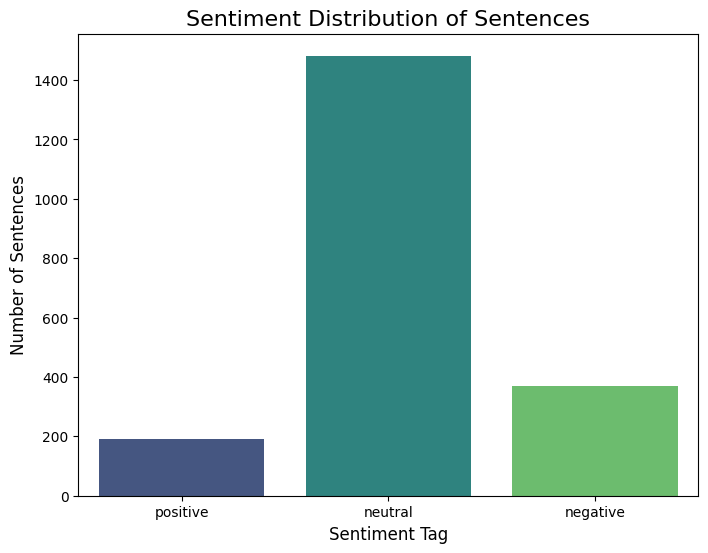

In [7]:
# ===================================================================
# CELL 7: FINAL DATA ANALYSIS - SENTIMENT DISTRIBUTION
# ===================================================================
print("--- Visualization of Final Data: Sentiment Distribution ---")
plt.figure(figsize=(8, 6))
sns.countplot(data=processed_df, x="sentimentTag", order=['positive', 'neutral', 'negative'], palette="viridis")
plt.title("Sentiment Distribution of Sentences", fontsize=16)
plt.xlabel("Sentiment Tag", fontsize=12)
plt.ylabel("Number of Sentences", fontsize=12)
plt.show()


--- Visualization of Final Data: Sentence Length ---


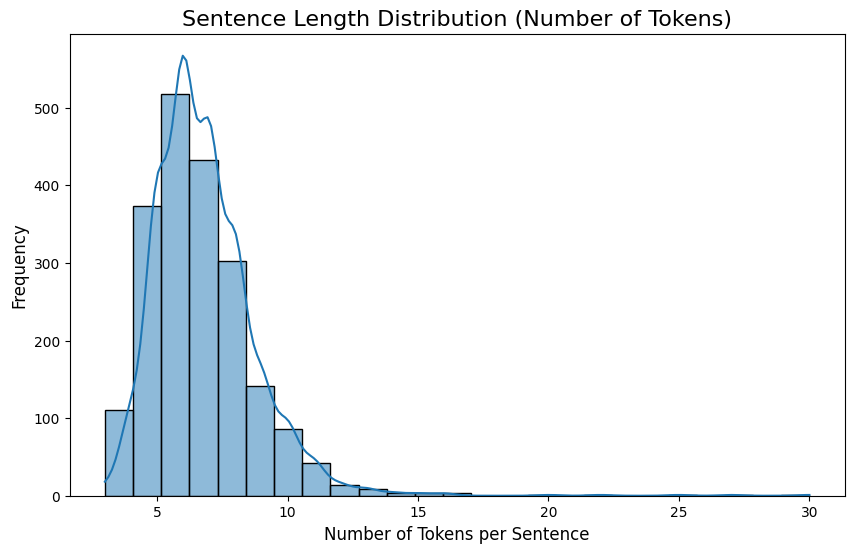

In [8]:
# ===================================================================
# CELL 8: FINAL DATA ANALYSIS - SENTENCE LENGTH
# ===================================================================
print("\n--- Visualization of Final Data: Sentence Length ---")
processed_df["sent_len"] = processed_df["tokens"].apply(len)

plt.figure(figsize=(10, 6))
sns.histplot(processed_df["sent_len"], bins=25, kde=True)
plt.title("Sentence Length Distribution (Number of Tokens)", fontsize=16)
plt.xlabel("Number of Tokens per Sentence", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()


--- Visualization of Final Data: Most Common Tokens ---


C:\Users\soozh\AppData\Local\Temp\ipykernel_2212\4083660739.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Count", y="Token", data=top_tokens_df, palette="plasma")


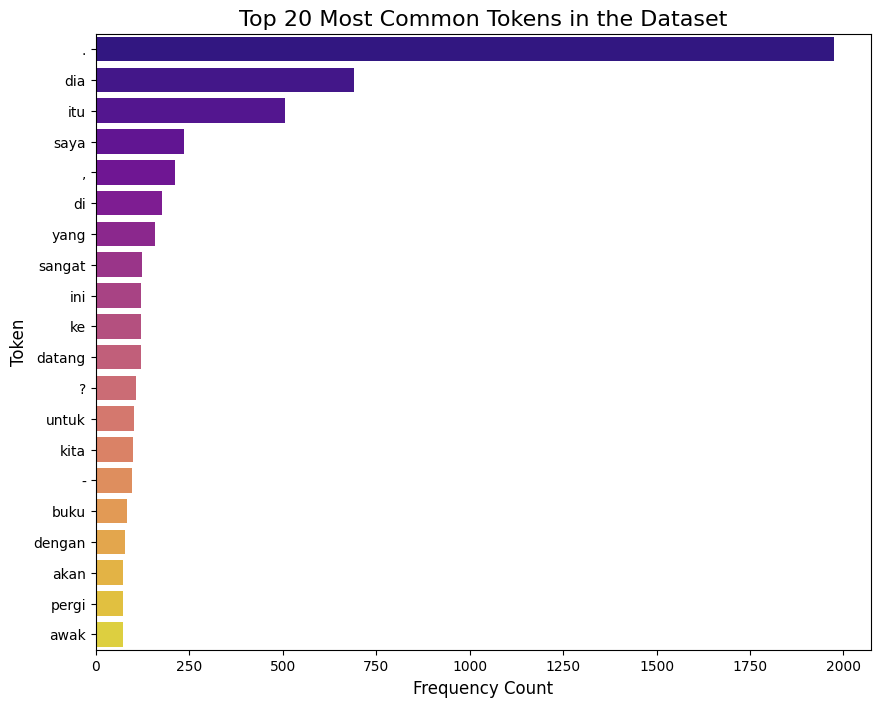

In [9]:
# ===================================================================
# CELL 9: FINAL DATA ANALYSIS - TOKEN FREQUENCY
# ===================================================================
print("\n--- Visualization of Final Data: Most Common Tokens ---")
all_tokens = [token for tokens_list in processed_df["tokens"] for token in tokens_list]
token_counts = Counter(all_tokens)
top_20_tokens = token_counts.most_common(20)
top_tokens_df = pd.DataFrame(top_20_tokens, columns=["Token", "Count"])

plt.figure(figsize=(10, 8))
sns.barplot(x="Count", y="Token", data=top_tokens_df, palette="plasma")
plt.title("Top 20 Most Common Tokens in the Dataset", fontsize=16)
plt.xlabel("Frequency Count", fontsize=12)
plt.ylabel("Token", fontsize=12)
plt.show()